code to generate a zadoff-chu sequence and figure our it usage

In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def zadoff_chu(N, u):
    q = 0
    N_0 = np.arange(0, N, 1)
    N_1 = np.arange(1, N + 1, 1)
    
    if N % 2 == 1:  # Odd length
        y = np.exp(-1j * u * np.pi / N * np.multiply(N_0, (N_1 + 2 * q)))
    else:  # Even length
        y = np.exp(-1j * u * np.pi / N * (N_0**2))
        
    return y   

' \nplt.subplot(2,1,2)\nplt.plot(t,np.imag(x_t)) '

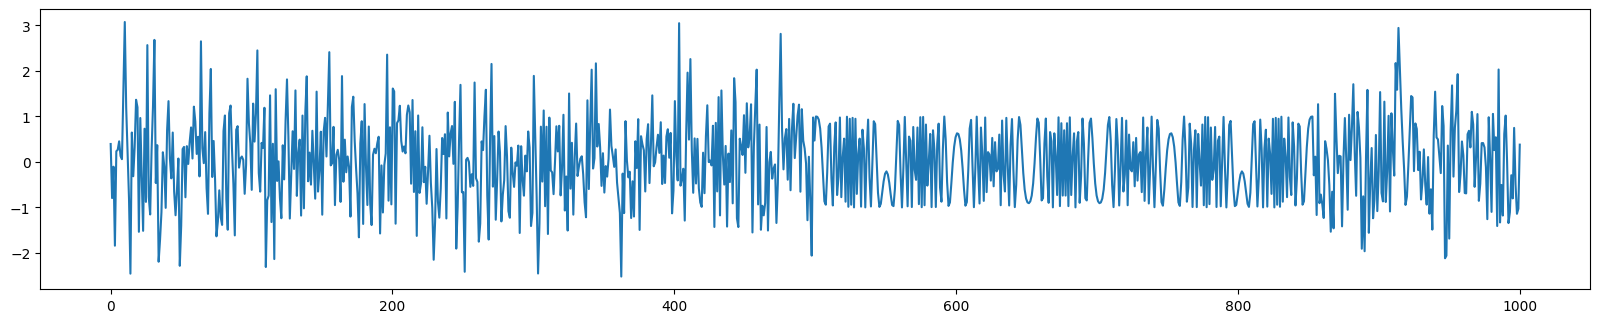

In [20]:
Tmax=1000
len_zadoff_chu=353
u_zadoff_chu=7

t=np.linspace(0,Tmax,Tmax)
zadoff_chu_seq=zadoff_chu(len_zadoff_chu,u_zadoff_chu)

pad_len = Tmax - len(zadoff_chu_seq)

noise = np.random.randn(pad_len)   # Gaussian noise (mean=0, std=1)

x_t = np.concatenate([zadoff_chu_seq, noise])

shift=500
x_t=np.roll(x_t,shift)

plt.figure(figsize=(20,8))
plt.subplot(2,1,1)
plt.plot(t,np.real(x_t))

""" 
plt.subplot(2,1,2)
plt.plot(t,np.imag(x_t)) """


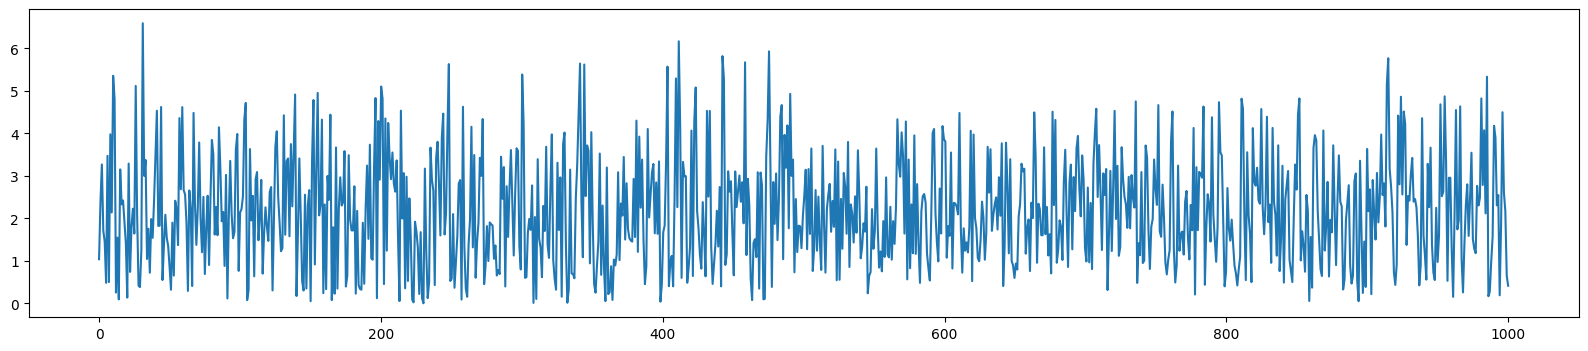

In [21]:
x_t=x_t+np.random.random(len(x_t))*4 #adding noise to the sequence to see the effect on correlation
plt.figure(figsize=(20,4))
plt.plot(t,np.abs(x_t))

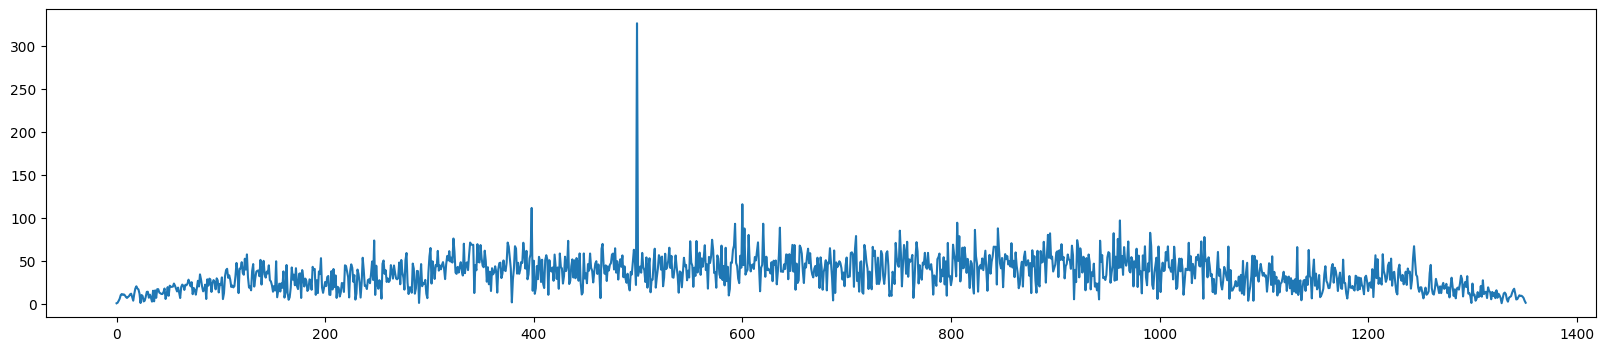

In [22]:
corr = np.correlate(zadoff_chu_seq, x_t, mode='full')

plt.figure(figsize=(20,4))
plt.plot(np.abs(corr))

use valid mode when detecting the sequence

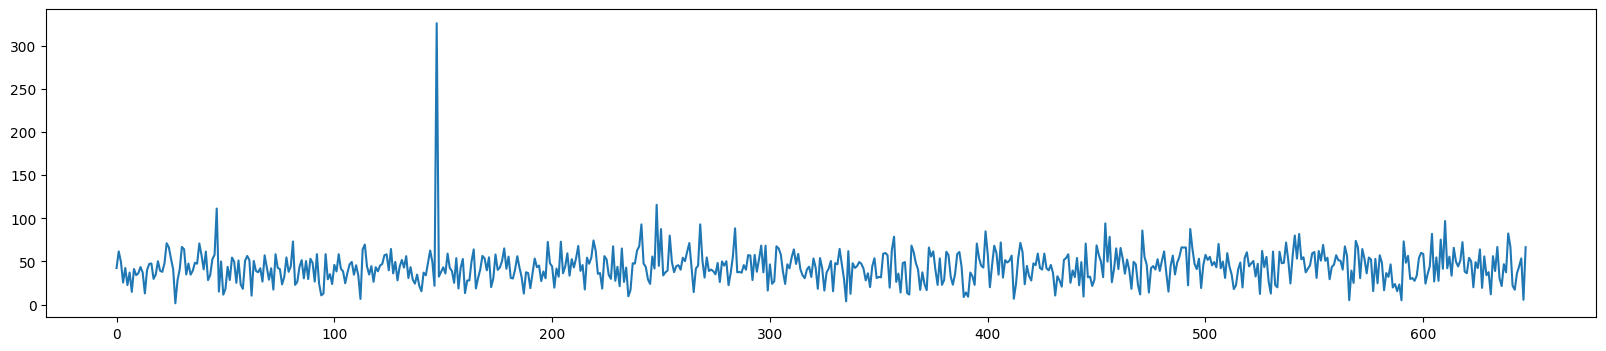

In [23]:
corr=np.correlate(zadoff_chu_seq, x_t, mode='valid')

plt.figure(figsize=(20,4))
plt.plot(abs(corr))

In [24]:
index = np.argmax(abs(corr))

print("Match at index:", len(corr)-index)

Match at index: 501


Looking at the effect of downsampling zadoff chu

In [25]:
ds_zadoff = np.zeros_like(zadoff_chu_seq)
ds_zadoff[::7] = zadoff_chu_seq[::7]

x_t = np.concatenate([zadoff_chu_seq, noise])

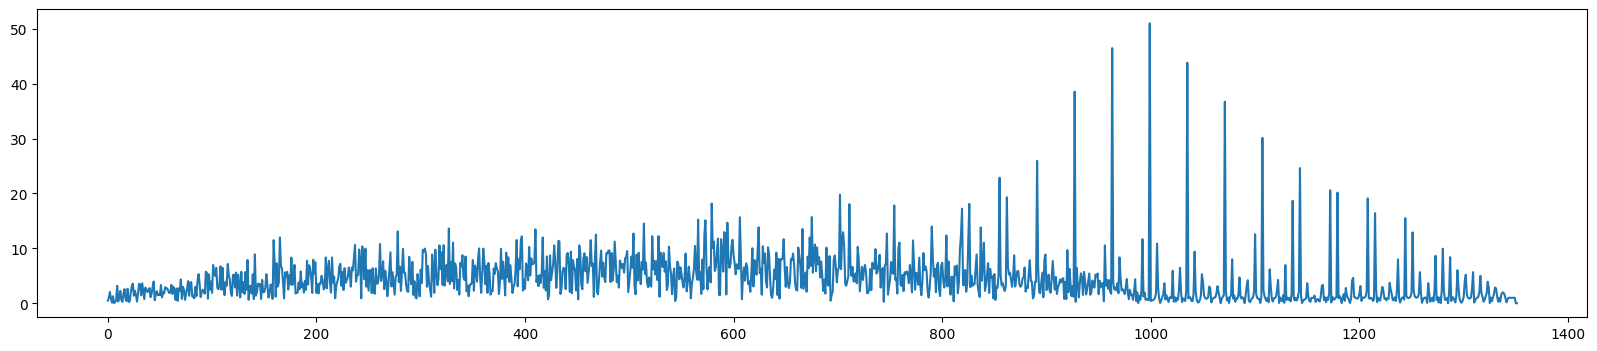

In [26]:
corr = np.correlate(ds_zadoff, x_t, mode='full')

plt.figure(figsize=(20,4))
plt.plot(np.abs(corr))

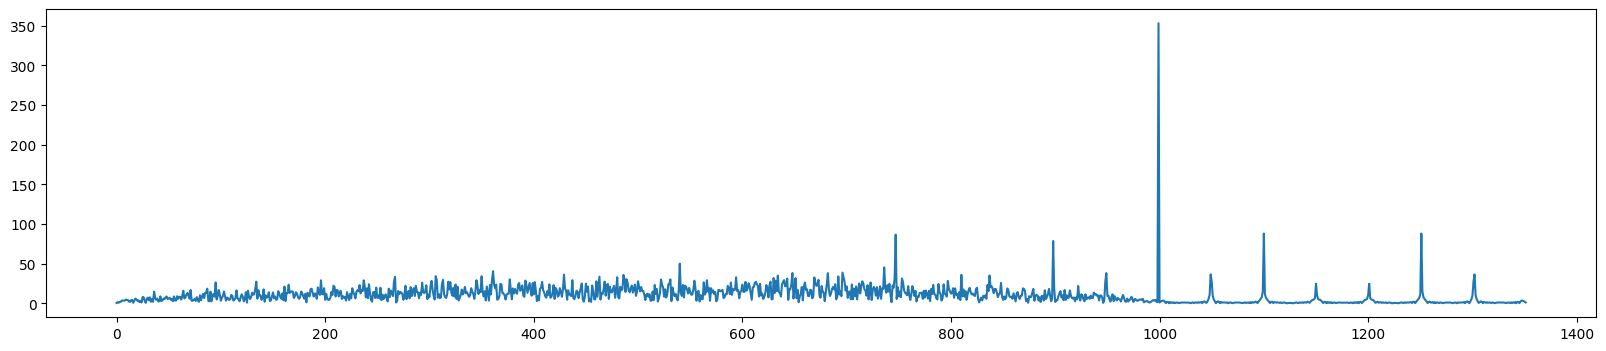

In [27]:
corr = np.correlate(zadoff_chu_seq, x_t, mode='full')

plt.figure(figsize=(20,4))
plt.plot(np.abs(corr))

/tmp/ipykernel_1316/839512606.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  ds_xt[::7] = x_t[::7]


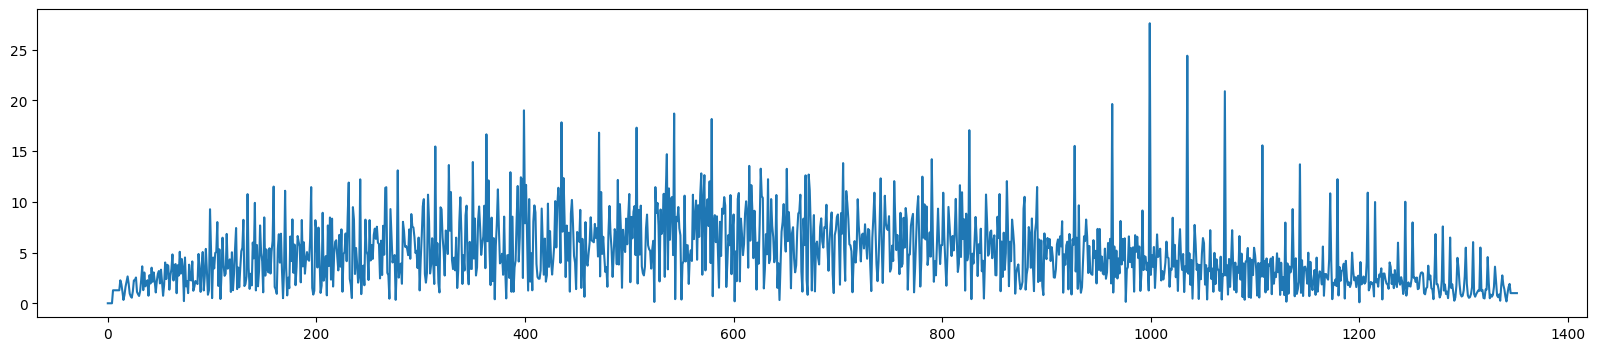

In [28]:
ds_xt=np.zeros(len(x_t))
ds_xt[::7] = x_t[::7]

corr = np.correlate(zadoff_chu_seq, ds_xt, mode='full')

plt.figure(figsize=(20,4))
plt.plot(np.abs(corr))

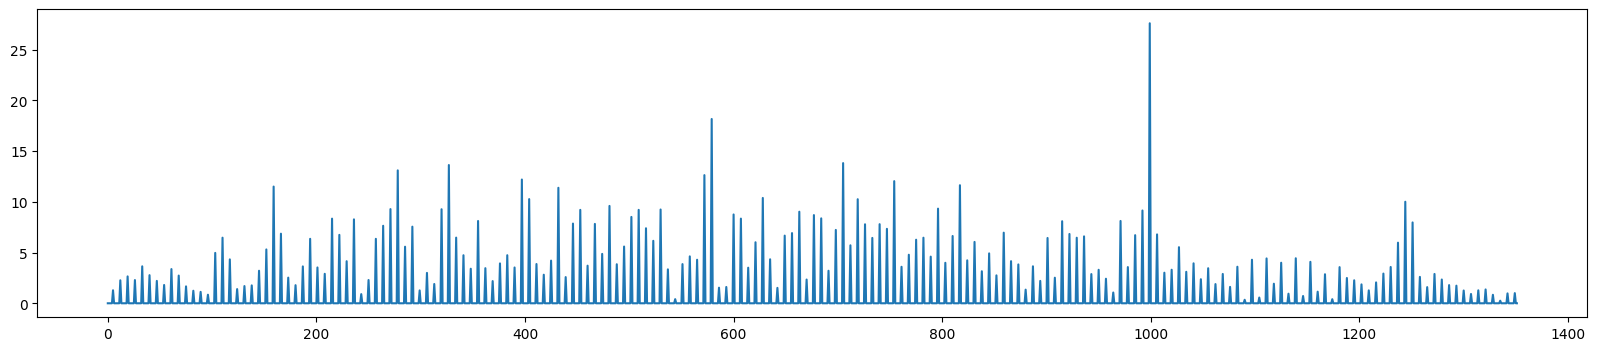

In [29]:
corr = np.correlate(ds_zadoff, ds_xt, mode='full')

plt.figure(figsize=(20,4))
plt.plot(np.abs(corr))

result: we can downsample by a lot and still get a good auto correlation